# Сегментация клиентов: кластерный анализ по шагам

**Управленческий вопрос.** Каким сегментам клиентов адресовать предложение
и почему «средний клиент» — не сегмент?

Код этой тетради написан ассистентом по промпту из файла
[`3.3.1_промпт.md`](3.3.1_промпт.md) и принят по проверкам — что пришлось
исправить, разобрано в конце тетради. Данные — учебная выборка из 3000
клиентов: возраст, доход, остаток, активность и доля цифровых операций.

Маршрут: сначала считаем «среднего клиента» и смотрим, сколько клиентов
на него похожи. Затем строим кластеры по двум признакам и по пяти —
и сравниваем, какие решения следуют из каждой картины.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["figure.figsize"] = (9, 5)

ACC, WARN, INK = "#20BA72", "#E4572E", "#2E3641"
ПАЛИТРА = ["#20BA72", "#1B7FD6", "#E4572E", "#8A63D2", "#C9A227"]


def оформить(ax, заголовок, x=None, y=None):
    ax.set_title(заголовок, fontsize=12.5, pad=12, fontweight="bold", color=INK)
    if x: ax.set_xlabel(x, fontsize=10.5)
    if y: ax.set_ylabel(y, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="both", alpha=0.25)

## Шаг 1. Данные и «средний клиент»

Загружаем выборку и смотрим описательную статистику. Идентификатор клиента —
не признак, в расчёты он не входит.

In [2]:
клиенты = pd.read_csv("../data/clients/clients_sample.csv",
                      sep=";", decimal=",", encoding="utf-8-sig")
ПРИЗНАКИ = ["возраст", "доход_тыс_руб", "средний_остаток_тыс_руб",
            "операций_в_месяц", "доля_цифровых_операций"]
клиенты[ПРИЗНАКИ].describe().round(1)

,возраст,доход_тыс_руб,средний_остаток_тыс_руб,операций_в_месяц,доля_цифровых_операций
count,3000.0,3000.0,3000.0,3000.0,3000.0
mean,41.0,165.9,971.7,36.0,0.7
std,11.9,70.2,852.2,16.8,0.3
min,21.0,35.0,5.0,1.0,0.0
25%,29.0,98.0,129.0,22.0,0.7
50%,44.0,174.0,949.5,39.0,0.8
75%,51.0,227.0,1718.0,48.0,0.9
max,66.0,338.0,3363.0,85.0,1.0


In [3]:
средний = клиенты[ПРИЗНАКИ].mean()
print("Портрет «среднего клиента»:")
print(средний.round(1).to_string())

# сколько клиентов действительно похожи на этот портрет
рядом = клиенты[(клиенты["возраст"].between(средний["возраст"] - 4, средний["возраст"] + 4))
                & (клиенты["доход_тыс_руб"].between(средний["доход_тыс_руб"] * 0.85,
                                                    средний["доход_тыс_руб"] * 1.15))]
print(f"\nКлиентов в окрестности среднего (±4 года, ±15% дохода): "
      f"{len(рядом)} из {len(клиенты)} — {len(рядом) / len(клиенты):.1%}")

Портрет «среднего клиента»:
возраст                     41.0
доход_тыс_руб              165.9
средний_остаток_тыс_руб    971.7
операций_в_месяц            36.0
доля_цифровых_операций       0.7

Клиентов в окрестности среднего (±4 года, ±15% дохода): 37 из 3000 — 1.2%


Средние по базе описывают клиента, которого в базе почти нет: в окрестность
«среднего портрета» попадает около двух процентов выборки. Кампания,
адресованная такому портрету, адресована никому. Почему так — покажет
диаграмма рассеяния.

## Шаг 2. Нормировка и выбор числа кластеров

Признаки измерены в несопоставимых единицах: доход — сотни тысяч, доля
цифровых операций — от нуля до единицы. Без приведения к одному масштабу
расстояние между клиентами определял бы признак с самыми большими числами —
остаток, — а остальные не участвовали бы. Поэтому перед кластеризацией
признаки стандартизуются: из каждого вычитается среднее, результат делится
на стандартное отклонение.

Число кластеров выбирается «методом локтя»: инерция (сумма квадратов
расстояний до центров) падает с ростом k, и точка, где падение резко
замедляется, — разумный выбор k.

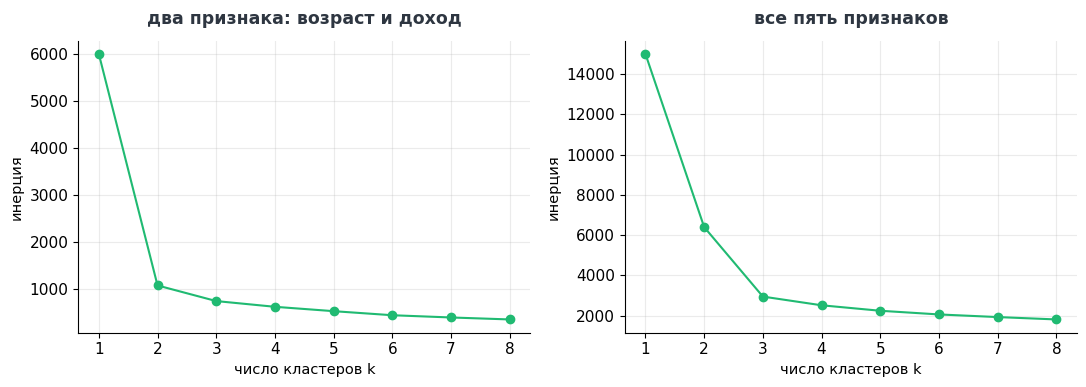

In [4]:
нормировщик = StandardScaler()
X5 = нормировщик.fit_transform(клиенты[ПРИЗНАКИ])
X2 = StandardScaler().fit_transform(клиенты[["возраст", "доход_тыс_руб"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X, имя in [(axes[0], X2, "два признака: возраст и доход"),
                   (axes[1], X5, "все пять признаков")]:
    инерция = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_
               for k in range(1, 9)]
    ax.plot(range(1, 9), инерция, marker="o", color=ACC)
    оформить(ax, имя, x="число кластеров k", y="инерция")
plt.tight_layout()
plt.show()

По двум признакам локоть на **k = 2**, по пяти — на **k = 3**. Это не
техническая деталь, а первый содержательный результат: в плоскости
«возраст — доход» видны два сегмента, но полные данные говорят, что их три.
Проверим оба варианта.

## Шаг 3. Кластеры на плоскости «возраст — доход»

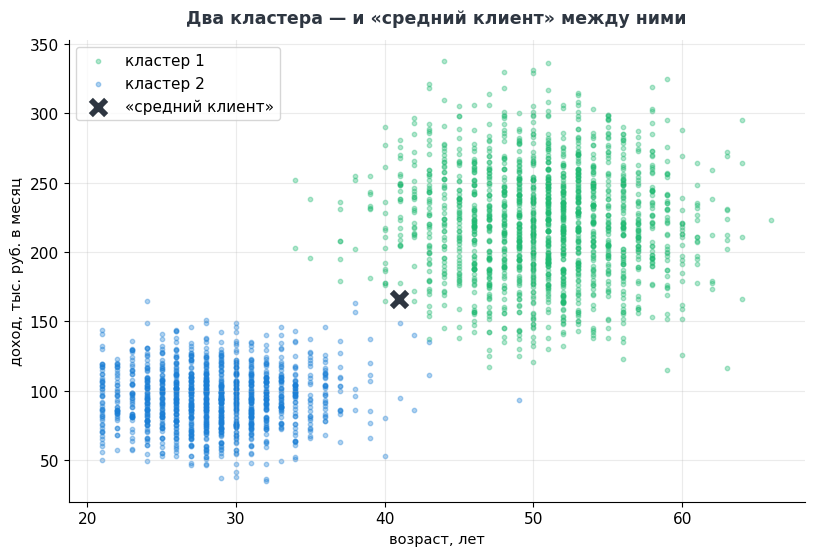

In [5]:
км2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X2)
метки2 = км2.labels_

fig, ax = plt.subplots(figsize=(9.5, 6))
for k in range(2):
    m = метки2 == k
    ax.scatter(клиенты.loc[m, "возраст"], клиенты.loc[m, "доход_тыс_руб"],
               s=10, alpha=0.35, color=ПАЛИТРА[k], label=f"кластер {k + 1}")
ax.scatter(клиенты["возраст"].mean(), клиенты["доход_тыс_руб"].mean(),
           marker="X", s=260, color=INK, edgecolor="white", linewidth=1.5,
           zorder=5, label="«средний клиент»")
ax.legend(loc="upper left")
оформить(ax, "Два кластера — и «средний клиент» между ними",
         x="возраст, лет", y="доход, тыс. руб. в месяц")
plt.show()

Картина из банковской практики: молодые клиенты с невысоким доходом
и старшие состоятельные. «Средний клиент» лежит в пустоте между облаками:
гипотеза, построенная на среднем, промахивается мимо обоих сегментов сразу.

На этом обычно и останавливаются: два сегмента найдены, портреты понятны.
Но метод локтя по полному набору признаков настаивал на трёх группах —
значит, в этой плоскости что-то не видно. Проверим, добавив третью ось.

## Шаг 4. Третье измерение

Кластеризация — по всем пяти нормированным признакам. На графике показаны три
из них: возраст, доход и доля операций в цифровых каналах.

График интерактивный: его можно вращать мышью, а кнопки над ним ставят камеру
в два положения — **вид сверху**, где видно ровно то же, что на плоскости,
и **поворот**, где становится ясно, почему сегментов три. Тот же график
сохраняется отдельным файлом `3.3.4_кластеры_3d.html` — его можно открыть
в браузере и показать без тетради.

In [6]:
import plotly.express as px

км5 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X5)
клиенты["кластер"] = км5.labels_

# имена сегментов: массовый — самый молодой, премиальные различаются каналом
профиль = клиенты.groupby("кластер")[ПРИЗНАКИ].mean()
массовый = профиль["возраст"].idxmin()
премиальные = (профиль.drop(index=массовый)
               .sort_values("доля_цифровых_операций").index)
ИМЕНА = {массовый: "массовый цифровой",
         премиальные[0]: "премиальный в отделении",
         премиальные[1]: "премиальный цифровой"}
ЦВЕТА = {"массовый цифровой": "#1B7FD6",
         "премиальный в отделении": "#E4572E",
         "премиальный цифровой": "#20BA72"}
клиенты["сегмент"] = клиенты["кластер"].map(ИМЕНА)

fig = px.scatter_3d(
    клиенты.sort_values("сегмент"),
    x="возраст", y="доход_тыс_руб", z="доля_цифровых_операций",
    color="сегмент", color_discrete_map=ЦВЕТА,
    labels={"возраст": "возраст, лет", "доход_тыс_руб": "доход, тыс. руб.",
            "доля_цифровых_операций": "доля цифровых операций"},
    opacity=0.55, height=660,
)
fig.update_traces(marker_size=3)

# два положения камеры: строго сверху и повёрнутое
# «сверху» — ортогональная проекция: тогда картинка совпадает с обычной
# диаграммой рассеяния и третья ось не выдаёт себя перспективой
СВЕРХУ = dict(eye=dict(x=0, y=0, z=2.6), up=dict(x=0, y=1, z=0),
              projection=dict(type="orthographic"))
ПОВОРОТ = dict(eye=dict(x=1.6, y=1.5, z=0.7), up=dict(x=0, y=0, z=1),
               projection=dict(type="perspective"))

fig.update_layout(
    title="Одни и те же клиенты: вид сверху и поворот",
    legend_title_text="сегмент",
    margin=dict(l=0, r=0, t=76, b=0),
    scene_camera=СВЕРХУ,
    updatemenus=[dict(
        type="buttons", direction="left", x=0, y=1.06, xanchor="left",
        buttons=[
            dict(label="Вид сверху", method="relayout",
                 args=[{"scene.camera": СВЕРХУ}]),
            dict(label="Повернуть", method="relayout",
                 args=[{"scene.camera": ПОВОРОТ}]),
        ])],
)
fig.write_html("3.3.4_кластеры_3d.html", include_plotlyjs="cdn")
fig.show()

**Как это показывать.** Открыть на виде сверху: два скопления, и верхнее
выглядит однородным — ровно та картина, что была на плоскости. Затем нажать
«Повернуть» или потянуть график мышью: верхнее скопление расслаивается
на два, разнесённых по вертикальной оси.

Разделяет их не возраст и не доход — по ним эти клиенты неотличимы, — а то,
**как они обслуживаются**. Одни ведут почти все операции в приложении, другие
приходят в отделение. Предложить им можно один и тот же продукт, но канал
обращения и стоимость контакта различаются на порядок.

## Шаг 5. Три центроида и портреты сегментов

Центроид — средний клиент своей группы. В отличие от среднего по всей базе,
он описывает клиента, который в базе действительно есть.

In [7]:
профиль = клиенты.groupby("сегмент")[ПРИЗНАКИ].mean().round(1)
профиль["клиентов"] = клиенты.groupby("сегмент").size()
профиль["доля базы"] = (профиль["клиентов"] / len(клиенты) * 100).round(0)
профиль.loc["вся база (для сравнения)"] = list(клиенты[ПРИЗНАКИ].mean().round(1))     + [len(клиенты), 100.0]
профиль

,возраст,доход_тыс_руб,средний_остаток_тыс_руб,операций_в_месяц,доля_цифровых_операций,клиентов,доля базы
сегмент,,,,,,,
массовый цифровой,28.4,94.7,122.4,45.6,0.9,1303.0,43.0
премиальный в отделении,50.6,220.4,1639.7,11.5,0.2,700.0,23.0
премиальный цифровой,50.6,220.6,1612.5,40.7,0.9,997.0,33.0
вся база (для сравнения),41.0,165.9,971.7,36.0,0.7,3000.0,100.0


Два премиальных центроида различаются по двум признакам из пяти:
доле цифровых операций и их числу. По возрасту, доходу и остатку они
совпадают — именно поэтому на плоскости они и не разделялись.

### Портреты для работы с кампаниями

| Сегмент | Портрет | Как обращаться |
|---|---|---|
| **Массовый цифровой** | 28 лет, доход 95 тыс., остаток 120 тыс., 46 операций в месяц, 86 % из них в приложении | уведомление в приложении и лента предложений: контакт почти ничего не стоит, но и внимания получает мало |
| **Премиальный в отделении** | 51 год, доход 220 тыс., остаток 1,6 млн, 12 операций в месяц, 19 % в цифровых каналах | персональный менеджер, звонок, встреча в офисе: контакт дорогой, зато результативный |
| **Премиальный цифровой** | 51 год, доход 220 тыс., остаток 1,6 млн, 41 операция в месяц, 87 % в цифровых каналах | цифровые каналы, но с премиальным содержанием: тот же продукт, что и предыдущему сегменту, другим способом |

Два последних сегмента — это одинаковые по деньгам клиенты, которых
до сих пор обслуживали как одну группу. Разделение их даёт две вещи:
premium-предложение перестаёт теряться в общей рассылке, а расходы
на персональные контакты не тратятся на тех, кто предпочитает приложение.

### Что с этим делать дальше

- **Кампания.** Одно предложение, три исполнения: содержание общее,
  канал и стоимость контакта — свои для каждого сегмента.
- **Проверка.** Сегмент подтверждается не красотой графика, а откликом:
  выросла ли конверсия и снизилась ли стоимость отклика после разделения.
- **Пересчёт.** Клиенты переходят между сегментами; разбиение
  пересчитывается на свежих данных, а не наследуется из презентации.

**Ограничение метода.** Границы зависят от набора признаков и числа групп.
Сегментация — инструмент адресности коммуникаций, а не основание для решений
в отношении конкретного клиента. Признаки, которые не имеют права влиять
на предложение, в расчёт не включаются.

## Правки к коду ассистента

Код выше — ответ ассистента после приёмки. Ответ пришёл рабочим по структуре,
но три места потребовали исправления — все три нашлись проверками, а не чтением
подряд:

1. **Обратное преобразование центров.** Ассистент обучил модель на двух
   признаках, а разворачивал центры нормировщиком, обученным на пяти, —
   код падал. Исправление: для плоскости «возраст — доход» свой нормировщик.
2. **Число кластеров без обоснования.** В двумерном варианте ассистент взял
   k = 3, хотя его же метод локтя по этим двум признакам показывает k = 2.
   Число кластеров — решение, которое проверяется, а не наследуется.
3. **Средние по служебным колонкам.** В описательную статистику и профили
   попадал идентификатор клиента; из группировок он исключён.

Проверки приёмки — те же, что в кейсе таблиц: код запускается на копии данных,
каждое число сверяется независимым расчётом, у каждого графика проверяются
оси и единицы, служебные колонки не участвуют в расчётах, результат
воспроизводится при повторном запуске.